# KCO Fragmentation Model

This notebook develops a practical starter implementation of a KCO-style fragmentation model for drill and blast analysis. The intent is to create a transparent, testable workflow in Jupyter first, then refine and migrate the logic into MiningSim once the behaviour, inputs, and outputs are understood.

The implementation used here combines a practical median fragment size estimate (`X50`) with a Swebrec size distribution function to generate a full particle size distribution (PSD). In this form, `X50` is influenced by key blast and rock mass variables including burden, spacing, bench height, hole diameter, explosive relative strength, rock factor, jointing, and density influence. The resulting PSD is then described using the Swebrec cumulative passing equation, with curve shape controlled by the `b` parameter and upper size limited by an estimated `Xmax`.

This notebook is intended as an engineering scaffold rather than a final or canonical KCO implementation. In practice, fragmentation models are typically adapted to site conditions and calibrated against measured PSD data such as sieve results, image analysis, or fragmentation monitoring systems. For that reason, this notebook includes simple multiplier-based tuning terms for both `X50` and `b`, along with a brute-force calibration routine that can be used to fit model predictions to measured passing data.

The notebook covers:
- blast input definition using a structured dataclass
- calculation of charge mass, rock volume, and powder factor
- estimation of `X50`, `b`, and `Xmax`
- generation of a Swebrec-based PSD
- extraction of `P20`, `P50`, and `P80`
- plotting of fragmentation curves
- simple sensitivity testing
- first-pass calibration against measured PSD data
- batch execution across multiple blasts in a tabular format

At this stage, the emphasis is on clarity, modularity, and calibration readiness. Later versions can extend this notebook to include site-specific blastability domains, explosive product effects, oversize and fines metrics, and downstream proxies relevant to excavation, crushing, and comminution performance.

## 1. Research – KCO Fragmentation Model

### Description

The KCO fragmentation model is an empirical–mechanistic blast fragmentation model developed to estimate the particle size distribution (PSD) produced by blasting. It is widely used in mine-to-mill optimisation and drill-and-blast design workflows because it links blast design parameters, explosive energy, and rock mass properties to predicted fragmentation outcomes.

In practice, the model generates a fragmentation distribution curve describing the percentage of material passing different sizes (e.g. P10, P50, P80, P90).

The approach combines:

- rock mass characterisation
- blast geometry and explosive energy parameters
- a fragmentation distribution function

Together these elements allow estimation of both characteristic fragment size and the overall PSD curve produced by blasting.

---

### Structure of the KCO Fragmentation Model

The KCO approach can be viewed as three conceptual layers:

1. Rock mass properties
2. Blast design and explosive energy
3. Fragment size distribution function

Typical workflow:
<div style="
  max-width: 640px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">

Rock properties + Blast design<br>
&nbsp;&nbsp;&nbsp;&nbsp;↓<br>
Energy delivered to rock mass<br>
&nbsp;&nbsp;&nbsp;&nbsp;↓<br>
Characteristic fragment size<br>
&nbsp;&nbsp;&nbsp;&nbsp;↓<br>
Fragment size distribution curve
</div>

---

### Rock Mass Characterisation

Rock mass parameters describe the breakability of the rock and how easily fractures propagate during blasting.

Typical parameters include:
| Parameter        | Meaning                       |
| ---------------- | ----------------------------- |
| UCS              | Uniaxial compressive strength |
| Density          | Rock density                  |
| Joint spacing    | Natural fracturing            |
| RQD / RMR        | Rock mass quality             |
| Young’s modulus  | Rock stiffness                |
| Tensile strength | Crack propagation resistance  |

In many fragmentation models these are simplified into a rock factor.

Rock Factor (RF)

RF is typically represented as a function of rock strength and structural properties:

`RF = f(UCS, jointing, density, stiffness)`

In simplified implementations it may be approximated using expressions such as:

`RF = UCS / (joint_factor × density)`

Higher rock factor values generally indicate harder, more massive rock, which tends to produce **coarser fragmentation**.

---

### Blast Geometry Parameters

Blast geometry controls **how explosive energy is distributed within the rock mass**.

| Parameter         | Meaning                             |
| ----------------- | ----------------------------------- |
| Burden (B)        | Distance from hole to free face     |
| Spacing (S)       | Distance between holes              |
| Bench height (H)  | Height of blast                     |
| Hole diameter (D) | Drill hole diameter                 |
| Stemming length   | Inert material at collar            |
| Subdrill          | Depth drilled below the bench floor |

---

### Explosive Energy Terms

Fragmentation is strongly influenced by the energy delivered per unit rock volume.

Powder Factor (PF)

`PF = Explosive mass / Rock volume`

Typical units include:

`kg explosive per m³ rock`

or

`kg explosive per tonne of rock`

Higher powder factors generally produce finer fragmentation, although the relationship is not perfectly linear.

---

### Energy Factor

Some KCO formulations incorporate explosive energy explicitly:

$Ev = PF × Q_e$

Where:
| Variable | Meaning                  |
| -------- | ------------------------ |
| $PF$     | Powder factor            |
| $Q_e$    | Explosive energy (MJ/kg) |

Ev therefore represents energy delivered per unit rock volume.

---

### Characteristic Fragment Size (X50)

The model predicts a **characteristic fragment size**, typically the median size of the distribution.

A common general form is:

$X_{50} = K × B^a × D^b × RF^c × E_{v}^{-d}$

Where:
| Parameter       | Meaning              |
| --------------- | -------------------- |
| $X50$           | Median fragment size |
| $B$             | Burden               |
| $D$             | Hole diameter        |
| $RF$            | Rock factor          |
| $E_v$           | Explosive energy     |
| $K, a, b, c, d$ | Empirical constants  |

Interpretation:

- Larger burden generally produces coarser fragments
- Larger hole diameter tends to produce coarser fragments
- Harder rock produces coarser fragments
- Higher explosive energy produces finer fragments

---

### Fragment Size Distribution Function

Once X50 is known, a distribution function is used to generate the full particle size distribution.

Two functions are commonly used:

• Rosin–Rammler distribution
• Swebrec distribution

#### Rosin–Rammler Distribution

$P(x) = 1 − exp[ − (x / xc)^n ]$

Where:
| Variable   | Meaning                |
| ---------- | ---------------------- |
| $P(x)$     | Percent passing size x |
| $xc$       | Characteristic size    |
| $n$        | Uniformity index       |

The uniformity index controls how broad the distribution is.

Higher n values produce **tighter size distributions**.

---

### Swebrec Distribution

The Swebrec function is often preferred in blast fragmentation modelling because it better represents both fines and coarse fragments.

A common form is:

$P(x) = 1 / [1 + ( ln(xmax / x) / ln(xmax / x50) )^b ]$

Where:
| Parameter   | Meaning               |
| ----------- | --------------------- |
| $x$         | fragment size         |
| $x50$       | median fragment size  |
| $xmax$      | maximum fragment size |
| $b$         | curve shape parameter |

The parameter $b$ controls the steepness of the PSD curve.

---

### Fragmentation Metrics Produced

Once the PSD curve is generated, common fragmentation metrics include:
| Metric | Meaning                        |
| ------ | ------------------------------ |
| P10    | 10% passing                    |
| P50    | Median size                    |
| P80    | Typical crusher feed indicator |
| P90    | Oversize risk                  |

These metrics are widely used in mine-to-mill modelling, where blast fragmentation influences downstream performance.

Example:

`P80 = 450 mm`

This value may be used to estimate:

- crusher throughput
- SAG mill energy consumption
- diggability
- shovel productivity

---

### Typical Implementation Workflow

A typical KCO implementation follows these steps:

#### Step 1 - Define rock parameters
<div style="
  max-width: 400px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">
UCS<br>
density<br>
jointing (joint spacing)<br>
rock factor<br>
</div>

#### Step 2 - Define blast design
<div style="
  max-width: 400px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">
burden<br>
spacing<br>
hole diameter<br>
bench height<br>
stemming<br>
subdrill<br>
</div>

#### Step 3 - Calculate explosive energy
<div style="
  max-width: 400px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">
powder factor<br>
explosive mass<br>
energy per unit rock volume<br>
</div>

#### Step 4 - Estimate median fragment size
<div style="
  max-width: 400px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">
X50 = f(blast design, rock properties, explosive energy)
</div>

#### Step 5 - Generate PSD curve<br>

<div style="
  max-width: 400px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">
Use Rosin-Rammler or Swebrec distribution<br>
</div>

#### Step 6 - Extract fragmentation metrics
<div style="
  max-width: 400px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">
P20<br>
P50<br>
P80<br>
P90<br>
</div>

---

### Applications of the KCO Model

In practical mining applications the model is used for:

Blast design optimisation
- selecting burden and spacing
- evaluating powder factor
- comparing explosive types

Mine-to-mill modelling
- estimating crusher throughput
- predicting SAG mill energy demand
- evaluating diggability
- assessing oversize risk

In simulation environments such as MiningSim the model can be used to represent:

`blast → fragmentation → loading → crushing → grinding`

---

### Typical Limitations

The KCO model is:

- ✔ useful for relative comparisons
- ✔ suitable for blast design optimisation
- ✔ compatible with mine-to-mill modelling

However:

- ✖ it is not a full physics-based rock fracture model
- ✖ calibration to site fragmentation data is typically required
- ✖ results are sensitive to rock factor assumptions

---

### Key Parameters Required

<div style="
  max-width: 400px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">
Rock properties:<br>
&nbsp;&nbsp;&nbsp;&nbsp;UCS<br>
&nbsp;&nbsp;&nbsp;&nbsp;density<br>
&nbsp;&nbsp;&nbsp;&nbsp;joint&nbsp;factor<br>
<br>
Blast geometry:<br>
&nbsp;&nbsp;&nbsp;&nbsp;burden<br>
&nbsp;&nbsp;&nbsp;&nbsp;spacing<br>
&nbsp;&nbsp;&nbsp;&nbsp;hole&nbsp;diameter<br>
&nbsp;&nbsp;&nbsp;&nbsp;bench&nbsp;height<br>
&nbsp;&nbsp;&nbsp;&nbsp;stemming<br>
&nbsp;&nbsp;&nbsp;&nbsp;powder&nbsp;factor<br>
<br>
Explosive parameters:<br>
&nbsp;&nbsp;&nbsp;&nbsp;explosive&nbsp;energy<br>
&nbsp;&nbsp;&nbsp;&nbsp;powder&nbsp;factor<br>
<br>
Distribution parameters:<br>
&nbsp;&nbsp;&nbsp;&nbsp;uniformity index or Swebrec b parameter<br>
</div>

Typical outputs include:
<div style="
  max-width: 400px;
  margin: 12px 0;
  text-align: left;
  padding: 16px;
  border: 1px solid #444;
  border-radius: 10px;
  background: #111;
  color: #fff;
  font-family: monospace;
">
X50<br>
PSD curve<br>
P80<br>
oversize fraction<br>
</div>

### References

> Ouchterlony, F. (2005). The Swebrec fragmentation function.\
> Ouchterlony, F. (2009). Fragmentation characterization and modelling.\
> Cunningham, C. V. B. (1983–1987). Kuz-Ram fragmentation model developments.\
> JSAIMM (2021). Application of the KCO model for blast fragmentation prediction.


In [23]:
import math
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Core input data structures

In [2]:
@dataclass
class BlastInputs:
    # Geometry
    burden_m: float
    spacing_m: float
    bench_height_m: float
    stemming_m: float
    hole_diameter_mm: float
    
    # Explosive / charging
    explosive_density_gcc: float
    relative_weight_strength: float  # relative to ANFO, or user-defined reference
    charge_length_m: Optional[float] = None
    
    # Rock mass / geology
    rock_factor_A: float = 7.0
    joint_factor_JF: float = 1.0
    density_influence_RDI: float = 1.0
    
    # Site / model tuning
    x50_multiplier: float = 1.0
    b_multiplier: float = 1.0
    n_uniformity: float = 1.0


@dataclass
class KCOResult:
    x_sizes_mm: np.ndarray
    passing_pct: np.ndarray
    x50_mm: float
    xmax_mm: float
    b: float
    p20_mm: float
    p50_mm: float
    p80_mm: float

## 3. Utility functions

In [3]:
def hole_area_m2(hole_diameter_mm: float) -> float:
    d_m = hole_diameter_mm / 1000.0
    return math.pi * (d_m ** 2) / 4.0


def charged_length_m(bench_height_m: float, stemming_m: float, charge_length_m: Optional[float]) -> float:
    if charge_length_m is not None:
        return charge_length_m
    return max(bench_height_m - stemming_m, 0.01)


def explosive_mass_per_hole_kg(
    hole_diameter_mm: float,
    explosive_density_gcc: float,
    charge_length_m: float
) -> float:
    """
    explosive_density_gcc: g/cc
    """
    density_kg_m3 = explosive_density_gcc * 1000.0
    volume_m3 = hole_area_m2(hole_diameter_mm) * charge_length_m
    return density_kg_m3 * volume_m3


def rock_volume_per_hole_m3(burden_m: float, spacing_m: float, bench_height_m: float) -> float:
    return burden_m * spacing_m * bench_height_m


def powder_factor_kg_m3(
    hole_diameter_mm: float,
    explosive_density_gcc: float,
    burden_m: float,
    spacing_m: float,
    bench_height_m: float,
    stemming_m: float,
    charge_length_m: Optional[float] = None
) -> float:
    cl = charged_length_m(bench_height_m, stemming_m, charge_length_m)
    m_exp = explosive_mass_per_hole_kg(hole_diameter_mm, explosive_density_gcc, cl)
    vol = rock_volume_per_hole_m3(burden_m, spacing_m, bench_height_m)
    return m_exp / max(vol, 1e-9)

## 4. ``X50`` estimation

Practical first-pass form - to be calibrated later.

In [4]:
def estimate_x50_mm(inputs: BlastInputs) -> float:
    """
    Practical starter estimate for X50.

    This form is structured so the main blastability drivers are visible:
    - burden / spacing / bench geometry
    - explosive energy
    - rock factor
    - jointing and density influence
    - site tuning multiplier

    You should calibrate this against measured PSD data.
    """
    B = inputs.burden_m
    S = inputs.spacing_m
    H = inputs.bench_height_m
    D_mm = inputs.hole_diameter_mm
    RWS = max(inputs.relative_weight_strength, 1e-6)
    A = max(inputs.rock_factor_A, 1e-6)
    JF = max(inputs.joint_factor_JF, 1e-6)
    RDI = max(inputs.density_influence_RDI, 1e-6)

    # A deliberately practical hybrid form:
    # - scales with blast geometry
    # - reduced by stronger explosives
    # - increased by harsher rock factor
    # - modified by jointing / density factors
    geom_term = (B * S * H) ** (1 / 3)
    diameter_term = (D_mm / 100.0) ** 0.2
    rock_term = (A * JF * RDI) ** 0.8
    energy_term = RWS ** (-0.8)

    x50_mm = 1000.0 * geom_term * diameter_term * rock_term * energy_term
    x50_mm *= inputs.x50_multiplier

    return max(x50_mm, 1.0)

## 5. ``b`` estimation for Swebrec

Two forms are included because different references and implementations use different approaches.

In [5]:
def estimate_b_from_geometry(inputs: BlastInputs) -> float:
    """
    Geometry-driven estimate for Swebrec b.
    Larger b generally gives a steeper curve shape.
    """
    B = max(inputs.burden_m, 1e-6)
    S = max(inputs.spacing_m, 1e-6)
    H = max(inputs.bench_height_m, 1e-6)
    T = max(inputs.stemming_m, 1e-6)

    ratio_bs = S / B
    ratio_ht = H / T

    b = 1.2 + 0.35 * ratio_bs + 0.08 * math.log(ratio_ht)
    b *= inputs.b_multiplier
    return max(b, 0.5)


def estimate_b_from_uniformity(inputs: BlastInputs) -> float:
    """
    Uniformity-based estimate.
    This is a simpler alternative where the user controls b more directly.
    """
    n = max(inputs.n_uniformity, 1e-6)
    b = 1.5 + 0.8 * n
    b *= inputs.b_multiplier
    return max(b, 0.5)

## 6. Maximum fragment size estimate

In [6]:
def estimate_xmax_mm(inputs: BlastInputs) -> float:
    """
    Practical estimate of top size.
    Often related to burden, spacing, toe conditions, structure, and confinement.
    """
    B = inputs.burden_m
    S = inputs.spacing_m
    D_mm = inputs.hole_diameter_mm

    xmax_mm = 1000.0 * max(1.2 * B, 0.8 * S) + 2.0 * D_mm
    return max(xmax_mm, 10.0)

## 7. Swebrec passing function

In [7]:
def swebrec_passing(x_mm: np.ndarray, x50_mm: float, xmax_mm: float, b: float) -> np.ndarray:
    """
    Swebrec cumulative passing function:
        P(x) = 1 / [1 + (ln(xmax / x) / ln(xmax / x50))^b]

    Returned as percent passing.
    """
    x = np.clip(np.asarray(x_mm, dtype=float), 1e-9, xmax_mm * 0.999999)
    denom = math.log(xmax_mm / max(x50_mm, 1e-9))
    denom = max(denom, 1e-9)

    ratio = np.log(xmax_mm / x) / denom
    ratio = np.clip(ratio, 0.0, None)

    passing_fraction = 1.0 / (1.0 + np.power(ratio, b))
    return 100.0 * passing_fraction

## 8. Percentile interpolation helper

In [8]:
def size_at_percent_passing(x_mm: np.ndarray, passing_pct: np.ndarray, target_pct: float) -> float:
    """
    Interpolate fragment size at a target percent passing.
    """
    x = np.asarray(x_mm, dtype=float)
    y = np.asarray(passing_pct, dtype=float)

    order = np.argsort(y)
    y_sorted = y[order]
    x_sorted = x[order]

    target_pct = float(np.clip(target_pct, y_sorted.min(), y_sorted.max()))
    return float(np.interp(target_pct, y_sorted, x_sorted))

## 9. Main model runner

In [9]:
def run_kco_model(
    inputs: BlastInputs,
    x_min_mm: float = 1.0,
    x_max_mm: Optional[float] = None,
    n_points: int = 200,
    b_method: str = "geometry"
) -> KCOResult:
    x50_mm = estimate_x50_mm(inputs)
    xmax_mm = estimate_xmax_mm(inputs) if x_max_mm is None else x_max_mm

    if b_method == "geometry":
        b = estimate_b_from_geometry(inputs)
    elif b_method == "uniformity":
        b = estimate_b_from_uniformity(inputs)
    else:
        raise ValueError("b_method must be 'geometry' or 'uniformity'")

    x_sizes_mm = np.geomspace(x_min_mm, xmax_mm * 0.999, n_points)
    passing_pct = swebrec_passing(x_sizes_mm, x50_mm=x50_mm, xmax_mm=xmax_mm, b=b)

    p20_mm = size_at_percent_passing(x_sizes_mm, passing_pct, 20.0)
    p50_mm = size_at_percent_passing(x_sizes_mm, passing_pct, 50.0)
    p80_mm = size_at_percent_passing(x_sizes_mm, passing_pct, 80.0)

    return KCOResult(
        x_sizes_mm=x_sizes_mm,
        passing_pct=passing_pct,
        x50_mm=x50_mm,
        xmax_mm=xmax_mm,
        b=b,
        p20_mm=p20_mm,
        p50_mm=p50_mm,
        p80_mm=p80_mm,
    )

## 10. Plotting helpers

In [10]:
def plot_fragmentation_curve(result: KCOResult, title: str = "KCO / Swebrec Fragmentation Curve") -> None:
    plt.figure(figsize=(9, 5.5))
    plt.semilogx(result.x_sizes_mm, result.passing_pct, linewidth=2)

    for pct, size in [(20, result.p20_mm), (50, result.p50_mm), (80, result.p80_mm)]:
        plt.axhline(pct, linestyle="--", linewidth=1)
        plt.axvline(size, linestyle="--", linewidth=1)
        plt.text(size, pct, f"  P{pct}={size:.1f} mm", va="bottom")

    plt.xlabel("Fragment size (mm)")
    plt.ylabel("Percent passing (%)")
    plt.title(title)
    plt.grid(True, which="both", alpha=0.3)
    plt.ylim(0, 100)
    plt.show()


def summarise_result(result: KCOResult) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "metric": ["X50", "Xmax", "b", "P20", "P50", "P80"],
            "value": [
                result.x50_mm,
                result.xmax_mm,
                result.b,
                result.p20_mm,
                result.p50_mm,
                result.p80_mm,
            ],
            "unit": ["mm", "mm", "-", "mm", "mm", "mm"],
        }
    )

## 11. Example Run

In [11]:
inputs = BlastInputs(
    burden_m=7.5,
    spacing_m=8.5,
    bench_height_m=12.0,
    stemming_m=4.0,
    hole_diameter_mm=251.0,
    explosive_density_gcc=1.15,
    relative_weight_strength=1.20,
    rock_factor_A=7.5,
    joint_factor_JF=1.1,
    density_influence_RDI=1.0,
    x50_multiplier=1.0,
    b_multiplier=1.0,
    n_uniformity=1.0,
)

result = run_kco_model(inputs, b_method="geometry")
summarise_result(result)

,metric,value,unit
0,X50,51401.214988,mm
1,Xmax,9502.000000,mm
2,b,1.684556,-
3,P20,9492.498000,mm
4,P50,9492.498000,mm
5,P80,9492.498000,mm


## 12. Plot the example

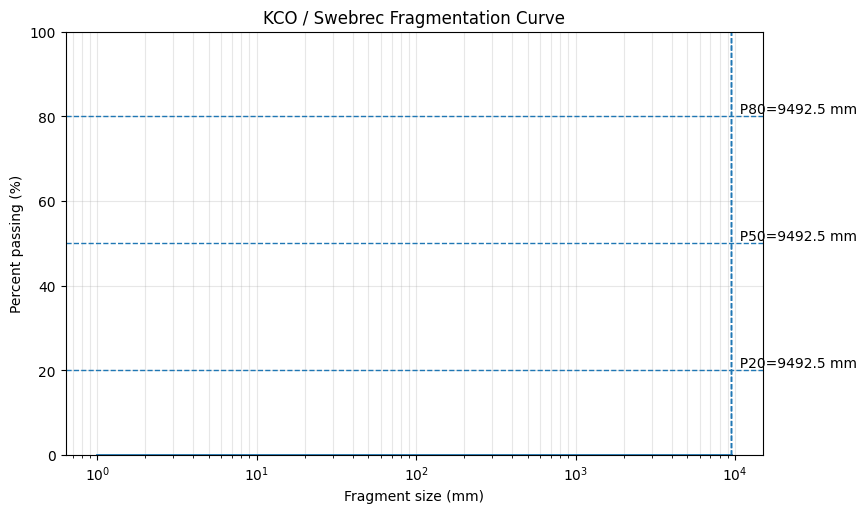

In [12]:
plot_fragmentation_curve(result)

## 13. Inspect powder factor and input summary

In [13]:
pf = powder_factor_kg_m3(
    hole_diameter_mm=inputs.hole_diameter_mm,
    explosive_density_gcc=inputs.explosive_density_gcc,
    burden_m=inputs.burden_m,
    spacing_m=inputs.spacing_m,
    bench_height_m=inputs.bench_height_m,
    stemming_m=inputs.stemming_m,
    charge_length_m=inputs.charge_length_m,
)

print("Inputs:")
for k, v in asdict(inputs).items():
    print(f"  {k}: {v}")

print(f"\nPowder factor: {pf:.3f} kg/m3")

Inputs:
  burden_m: 7.5
  spacing_m: 8.5
  bench_height_m: 12.0
  stemming_m: 4.0
  hole_diameter_mm: 251.0
  explosive_density_gcc: 1.15
  relative_weight_strength: 1.2
  charge_length_m: None
  rock_factor_A: 7.5
  joint_factor_JF: 1.1
  density_influence_RDI: 1.0
  x50_multiplier: 1.0
  b_multiplier: 1.0
  n_uniformity: 1.0

Powder factor: 0.595 kg/m3


## 14. Sensitivity testing

Helps to understand whether the model behaves sensibly before calibration.

In [14]:
def sensitivity_on_burden(base_inputs: BlastInputs, burdens: List[float]) -> pd.DataFrame:
    rows = []
    for burden in burdens:
        trial = BlastInputs(**asdict(base_inputs))
        trial.burden_m = burden
        res = run_kco_model(trial)

        rows.append(
            {
                "burden_m": burden,
                "x50_mm": res.x50_mm,
                "p20_mm": res.p20_mm,
                "p50_mm": res.p50_mm,
                "p80_mm": res.p80_mm,
            }
        )
    return pd.DataFrame(rows)


df_sens = sensitivity_on_burden(inputs, burdens=[6.5, 7.0, 7.5, 8.0, 8.5])
df_sens

,burden_m,x50_mm,p20_mm,p50_mm,p80_mm
0,6.5,49006.920796,8293.698,8293.698,8293.698
1,7.0,50232.598389,8893.098,8893.098,8893.098
2,7.5,51401.214988,9492.498,9492.498,9492.498
3,8.0,52518.981176,10091.898,10091.898,10091.898
4,8.5,53591.091866,10691.298,10691.298,10691.298


## 15. Plot sensitivity

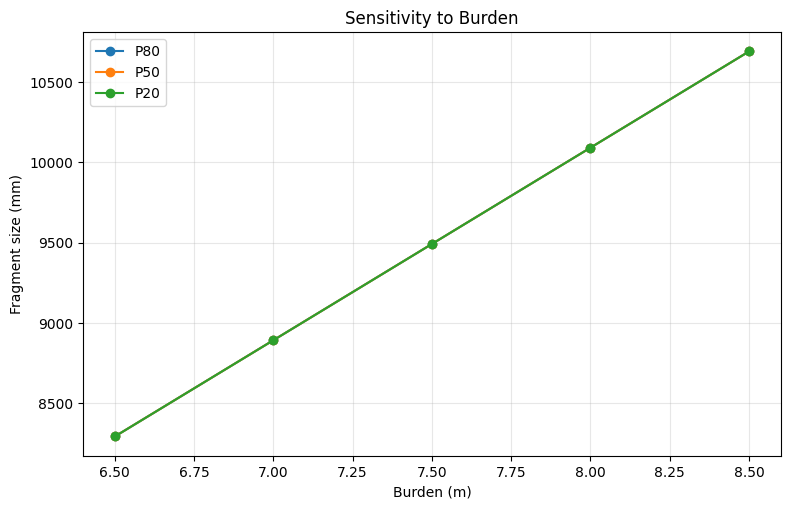

In [15]:
plt.figure(figsize=(9, 5.5))
plt.plot(df_sens["burden_m"], df_sens["p80_mm"], marker="o", label="P80")
plt.plot(df_sens["burden_m"], df_sens["p50_mm"], marker="o", label="P50")
plt.plot(df_sens["burden_m"], df_sens["p20_mm"], marker="o", label="P20")
plt.xlabel("Burden (m)")
plt.ylabel("Fragment size (mm)")
plt.title("Sensitivity to Burden")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 16. Calibration scaffold against measured PSD data

This is a simple brute-force starter. Later to be replaced with ``scipy.optimize``

In [16]:
def objective_measured_vs_model(
    measured_sizes_mm: np.ndarray,
    measured_passing_pct: np.ndarray,
    inputs: BlastInputs,
    x50_multiplier: float,
    b_multiplier: float,
    b_method: str = "geometry"
) -> float:
    trial = BlastInputs(**asdict(inputs))
    trial.x50_multiplier = x50_multiplier
    trial.b_multiplier = b_multiplier

    result = run_kco_model(trial, b_method=b_method)

    model_passing = np.interp(measured_sizes_mm, result.x_sizes_mm, result.passing_pct)
    err = np.mean((model_passing - measured_passing_pct) ** 2)
    return float(err)


def brute_force_calibrate(
    measured_sizes_mm: np.ndarray,
    measured_passing_pct: np.ndarray,
    inputs: BlastInputs,
    x50_range: Tuple[float, float] = (0.5, 1.5),
    b_range: Tuple[float, float] = (0.5, 1.5),
    n_x50: int = 31,
    n_b: int = 31,
    b_method: str = "geometry"
) -> Dict[str, float]:
    best = {
        "rmse_like": float("inf"),
        "x50_multiplier": None,
        "b_multiplier": None,
    }

    x50_vals = np.linspace(x50_range[0], x50_range[1], n_x50)
    b_vals = np.linspace(b_range[0], b_range[1], n_b)

    for x50_mult in x50_vals:
        for b_mult in b_vals:
            mse = objective_measured_vs_model(
                measured_sizes_mm=measured_sizes_mm,
                measured_passing_pct=measured_passing_pct,
                inputs=inputs,
                x50_multiplier=x50_mult,
                b_multiplier=b_mult,
                b_method=b_method,
            )

            if mse < best["rmse_like"]:
                best["rmse_like"] = mse
                best["x50_multiplier"] = x50_mult
                best["b_multiplier"] = b_mult

    return best

## 17. Example calibration run

Replace with measured sieve / image-analysis / WipFrag / Split / FRAGTrack data.

In [17]:
measured_sizes_mm = np.array([10, 25, 50, 75, 100, 150, 250, 400, 600, 900], dtype=float)
measured_passing_pct = np.array([8, 18, 32, 42, 50, 62, 76, 87, 94, 98], dtype=float)

best_fit = brute_force_calibrate(
    measured_sizes_mm=measured_sizes_mm,
    measured_passing_pct=measured_passing_pct,
    inputs=inputs,
    x50_range=(0.6, 1.4),
    b_range=(0.7, 1.3),
    n_x50=41,
    n_b=41,
)

best_fit

{'rmse_like': 4130.499999933166, 'x50_multiplier': 0.6, 'b_multiplier': 0.7}

## 18. Apply calibration and compare

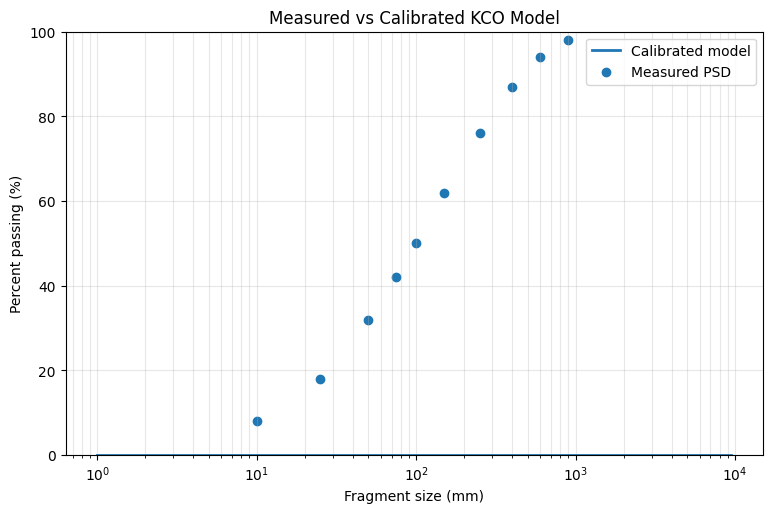

,metric,value,unit
0,X50,30840.728993,mm
1,Xmax,9502.000000,mm
2,b,1.179189,-
3,P20,9492.498000,mm
4,P50,9492.498000,mm
5,P80,9492.498000,mm


In [18]:
cal_inputs = BlastInputs(**asdict(inputs))
cal_inputs.x50_multiplier = best_fit["x50_multiplier"]
cal_inputs.b_multiplier = best_fit["b_multiplier"]

cal_result = run_kco_model(cal_inputs)

plt.figure(figsize=(9, 5.5))
plt.semilogx(cal_result.x_sizes_mm, cal_result.passing_pct, linewidth=2, label="Calibrated model")
plt.scatter(measured_sizes_mm, measured_passing_pct, label="Measured PSD")
plt.xlabel("Fragment size (mm)")
plt.ylabel("Percent passing (%)")
plt.title("Measured vs Calibrated KCO Model")
plt.grid(True, which="both", alpha=0.3)
plt.ylim(0, 100)
plt.legend()
plt.show()

summarise_result(cal_result)

## 19. Batch run for multiple blasts

This is the part that will later map into MiningSim

In [19]:
def run_blast_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, r in df.iterrows():
        inputs = BlastInputs(
            burden_m=r["burden_m"],
            spacing_m=r["spacing_m"],
            bench_height_m=r["bench_height_m"],
            stemming_m=r["stemming_m"],
            hole_diameter_mm=r["hole_diameter_mm"],
            explosive_density_gcc=r["explosive_density_gcc"],
            relative_weight_strength=r["relative_weight_strength"],
            rock_factor_A=r.get("rock_factor_A", 7.0),
            joint_factor_JF=r.get("joint_factor_JF", 1.0),
            density_influence_RDI=r.get("density_influence_RDI", 1.0),
            x50_multiplier=r.get("x50_multiplier", 1.0),
            b_multiplier=r.get("b_multiplier", 1.0),
            n_uniformity=r.get("n_uniformity", 1.0),
        )

        result = run_kco_model(inputs)

        rows.append(
            {
                "blast_id": r["blast_id"],
                "x50_mm": result.x50_mm,
                "xmax_mm": result.xmax_mm,
                "b": result.b,
                "p20_mm": result.p20_mm,
                "p50_mm": result.p50_mm,
                "p80_mm": result.p80_mm,
            }
        )

    return pd.DataFrame(rows)

## 20. Example batch dataset

In [20]:
df_blasts = pd.DataFrame(
    [
        {
            "blast_id": "BLAST_001",
            "burden_m": 7.5,
            "spacing_m": 8.5,
            "bench_height_m": 12.0,
            "stemming_m": 4.0,
            "hole_diameter_mm": 251.0,
            "explosive_density_gcc": 1.15,
            "relative_weight_strength": 1.20,
            "rock_factor_A": 7.5,
            "joint_factor_JF": 1.1,
            "density_influence_RDI": 1.0,
        },
        {
            "blast_id": "BLAST_002",
            "burden_m": 8.0,
            "spacing_m": 9.0,
            "bench_height_m": 12.0,
            "stemming_m": 4.2,
            "hole_diameter_mm": 270.0,
            "explosive_density_gcc": 1.20,
            "relative_weight_strength": 1.25,
            "rock_factor_A": 8.2,
            "joint_factor_JF": 1.0,
            "density_influence_RDI": 1.1,
        },
    ]
)

df_batch_results = run_blast_dataframe(df_blasts)
df_batch_results

,blast_id,x50_mm,xmax_mm,b,p20_mm,p50_mm,p80_mm
0,BLAST_001,51401.214988,9502.0,1.684556,9492.498,9492.498,9492.498
1,BLAST_002,56460.911700,10140.0,1.677736,10129.860,10129.860,10129.860
